In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom8/output',
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([5e2, 5e2, 5e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)





The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:
arepo_length = snap['0_Coordinates'].uq
density_unit = snap['0_Density'].uq
kpc = snap.uq('kpc')

filter_length_max = (widths[0]/5)*np.ones(snap['0_Diameters'].shape)*arepo_length

mhat = tc.MexicanHatPowerSpectrum(snap, center, widths, npix=256, orientation=None, 
                        search_radius=filter_length_max.value)

Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [4]:

def enforce_hermitian(amplitude_matrix):
    ## this is for odd matrices
    amplitudes = amplitude_matrix.copy()
    Nx, Ny, Nz = amplitudes.shape
    for kk in range(0,Nz//2):
        amplitudes[:,:,kk]=np.conj(np.flip(amplitudes)[:,:,kk])
    
    amplitudes[:Nx//2+1,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,:Ny//2+1,Nz//2])
    amplitudes[:Nx//2+1,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[:Nx//2+1,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,Ny//2+1:,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,Ny//2+1:,Nz//2])
    amplitudes[Nx//2+1:,:Ny//2+1,Nz//2]=np.conj(np.flip(amplitudes)[Nx//2+1:,:Ny//2+1,Nz//2])

    return amplitudes

In [5]:
def P1d(FFTw, K2, widths):

    # FFTw and K2 have the same shape:
    # (Nx,Ny,Nz) (for complex transform)

    Nx, Ny, Nz = FFTw.shape
    Lx, Ly, Lz = widths

    kxmax = (2.0*np.pi/Lx)*(Nx//2)
    kymax = (2.0*np.pi/Ly)*(Ny//2)
    kzmax = (2.0*np.pi/Lz)*(Nz//2)


    kmax = np.sqrt(kxmax**2 + kymax**2 + kzmax**2)
    kmin = 0
    nbin = int(kmax/(2.0*np.pi/np.min(widths) ) + 0.5)
    deltak = 2.0*np.pi/np.min(widths)

    spectrum_1d = np.zeros(nbin)
    wavevec = np.arange(nbin)*deltak

    for i in range(Nx):
        for j in range(Ny):
            for k in range(Nz):

                m = int( np.floor( pow( K2[i,j,k], 0.5 ) / (deltak) + 0.5 ) )
                if (m < nbin):
                    spectrum_1d[m] += np.real( FFTw[ i,j,k] * np.conj( FFTw[i,j,k] ) ) / (Nx*Ny*Nz)**2

    spectrum_1d *= (2.*np.pi/deltak)*(Lx*Ly*Lz)

    energy_fourier_space = np.sum(spectrum_1d*deltak/(2.0*np.pi))
    print('energy (fourier space) = %.4e'%(energy_fourier_space))
    return spectrum_1d, wavevec

In [6]:
def gaussian_profile(x,y,z,sigma):
    return np.exp(-0.5*(x**2+y**2+z**2)/sigma**2)/(np.sqrt(2.*np.pi)*sigma)**3

In [7]:
widths_slicer = widths.copy()
widths_slicer[2] = 0.
center_slicer = center.copy
slicer = pa.Slicer(snap, center_slicer, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [8]:

# ## generate Kolmogorov IC
nmax = 33
nfreq_tot = nmax**3
sigma = 100
rng = np.random.default_rng(seed=456789)

x = snap['0_Coordinates'][mhat.index][:, 0].value - center[0].value
y = snap['0_Coordinates'][mhat.index][:, 1].value - center[1].value
z = snap['0_Coordinates'][mhat.index][:, 2].value - center[2].value

kx_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[0])
ky_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[1])
kz_vec = np.arange(-(nmax-1)//2,(nmax-1)//2+1)*(2.0*np.pi/widths[2])

KX, KY, KZ = np.meshgrid(kx_vec, ky_vec, kz_vec, sparse=False, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2 
phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(nmax,nmax,nmax))

K2min = (2.0*np.pi/widths[0])**2 + (2.0*np.pi/widths[1])**2 + (2.0*np.pi/widths[2])**2
# K2min *= 9
power_law_exponent = -5./3.
# energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
# ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
ampl = np.zeros(K2.shape)
# ampl = np.where(K2>9*K2min,1e-3*np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
ampl = np.where(K2==0,2.*np.pi,ampl)

amplitudes_rho_fluct = nfreq_tot*ampl*np.exp(1j*phases_rho)
# amplitudes_rho_fluct *= np.exp(1j*0.5*(KX*widths[0] + KY*widths[1] + KZ*widths[2]))
amplitudes_rho_fluct = enforce_hermitian(amplitudes_rho_fluct)

phases_rho_gauss = 0.5*(KX*widths[0] + KY*widths[1] + KZ*widths[2])
amplitudes_rho_backgr = nfreq_tot*np.exp(-0.5*K2*sigma**2)*np.exp(1j*0.0)  

fluct_rhofield = np.zeros(snap['0_Density'].shape)
background_rhofield = np.zeros(snap['0_Density'].shape)

## redo this with finufft 
fluct_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho_fluct/(nfreq_tot)   , eps=1e-10, isign=-1))
                             
background_rhofield[mhat.index] = np.real(finufft.nufft3d2(((2.0*np.pi/widths[0])*x)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[1])*y)%(2.*np.pi), 
                                                        ((2.0*np.pi/widths[2])*z)%(2.*np.pi), 
                             amplitudes_rho_backgr/(nfreq_tot)   , eps=1e-10, isign=-1))


snap['0_synthetic_rhofield'] = background_rhofield * (fluct_rhofield) * density_unit
# snap['0_synthetic_rhofield'] = background_rhofield * (1.0) * density_unit


In [9]:
fluct_rhofield[mhat.index].min()

-3.3582640696950277

In [10]:
background_rhofield[mhat.index].max()

7.936212206895713

In [11]:
import scipy.ndimage

In [12]:
amplitudes_rho_tot = scipy.ndimage.convolve(amplitudes_rho_backgr,
                                            amplitudes_rho_fluct,
                                            mode='constant',
                                            cval=0.0)

In [22]:
## prepare deposit class
ngrid = 64
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=ngrid, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="PCS")


In [23]:

## deposit density to cartesian grid
density_cartesian = depo.deposit_variable('0_synthetic_rhofield', weight='0_Volume')

In [24]:
density_cartesian.max()

<PaicosQuantity 8.22185866 small_h2 arepo_density / small_a3>

Text(0.5, 0.95, 'Density field (cut box)')

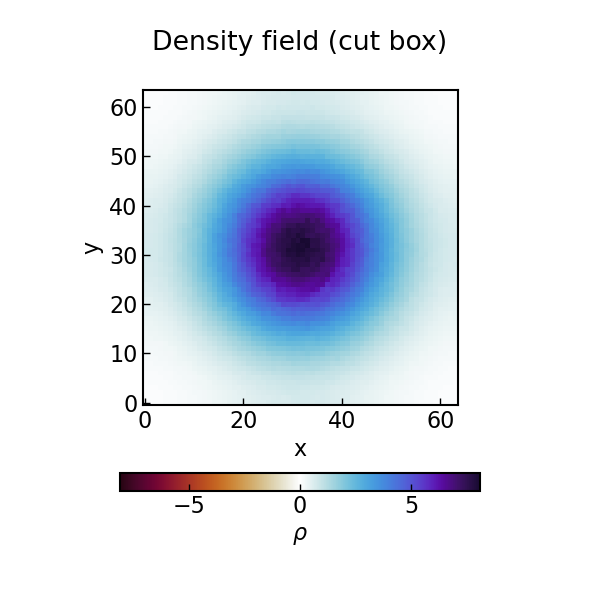

In [25]:

dens_cart_cut = density_cartesian[:,:,int(ngrid//2)-1].value
vmax = np.max(np.abs(dens_cart_cut))
vmin = -vmax
norm = Normalize(vmin=vmin,vmax=vmax)
# cmap = cmr.fall
cmap = cmr.fusion

fig, axes = plt.subplots(figsize=(6,6),sharex=True, sharey=True)

im1 = axes.imshow(
    dens_cart_cut, origin='lower', norm=norm, cmap=cmap)

axes.set_xlabel('x')
axes.set_ylabel('y')

cbar = fig.colorbar(im1, orientation='horizontal',shrink=0.75)
cbar.set_label(r'$\rho$')

fig.subplots_adjust(top=0.85,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Density field (cut box)',y=0.95)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)


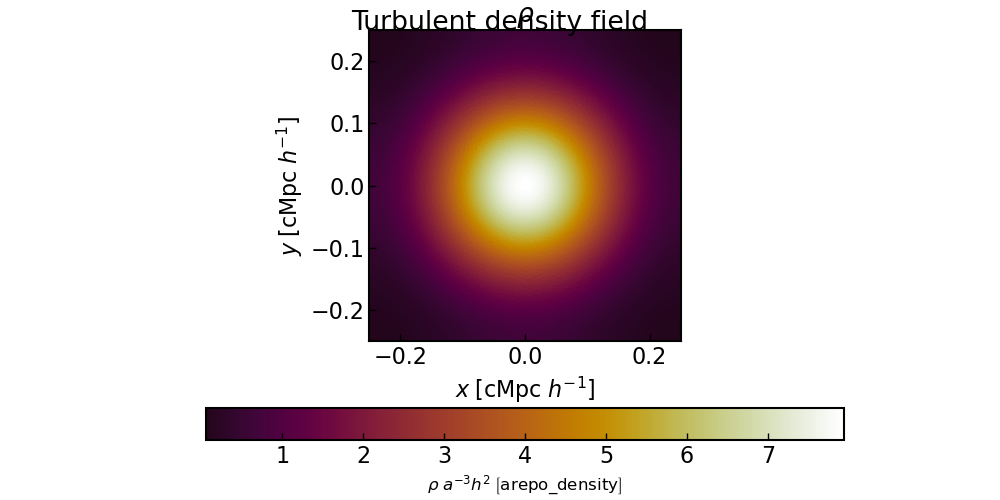

In [17]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import LogLocator
from matplotlib.patches import Circle

RHO = slicer.slice_variable(snap['0_synthetic_rhofield'])
# RHO = slicer.slice_variable(snap['0_Density'])
# RHO_turb = slicer.slice_variable(turbrho)
# RHO_smooth = slicer.slice_variable(smoothrho)

vmin = RHO.value.min()
vmax = RHO.value.max()
norm0 = Normalize(vmin=vmin,vmax=vmax)


cmap0 = cmr.fall
cmap = cmr.prinsenvlag_r
cmap1 = cmr.rainforest
cmap2 = cmr.eclipse

fig, axes = plt.subplots(1,1, figsize=(10,5),sharex=True, sharey=True)

im00 = axes.imshow(
    RHO.value, origin='lower', cmap=cmap0, norm=norm0, extent=extent.value)

axes.set_title(r'$\rho$')


# for i in range(3):
axes.set_xlabel(extent.label('x'))

# for i in range(3):
axes.set_ylabel(extent.label('y'))

cbar00 = fig.colorbar(im00, orientation='horizontal',shrink=0.75)
cbar00.set_label(RHO.label('\\rho'),fontsize=12)


fig.subplots_adjust(top=0.94,
bottom=0.05,
left=0.1,
right=0.95,
hspace=0.15,
wspace=0.15)

fig.suptitle('Turbulent density field',y=0.98)
# plt.savefig('./Plots/iterative/%s_double_bump_density_fixed_filter_paper.pdf'%(filter_type), dpi=400)

plt.show()


In [26]:
## different usages of power_spectrum1d method

# basic 
powerspectr_basic, k1d_basic, (KX_basic, KY_basic, KZ_basic, hat_var_basic) = depo.power_spectrum1d(density_cartesian)

# with zero-padding
powerspectr_padded, k1d_padded, (KX_padded, KY_padded, KZ_padded, hat_var_padded) = depo.power_spectrum1d(density_cartesian,
                                                          npads=6)

# with windowing
powerspectr_hann, k1d_hann, (KX_hann, KY_hann, KZ_hann, hat_var_hann) = depo.power_spectrum1d(density_cartesian,
                                                          window=scipy.signal.windows.hann)

energy (real space) = 3.3819e+08
energy (fourier space) = 3.3820e+08
energy (real space) = 3.3819e+08
energy (fourier space) = 3.3819e+08
energy (real space) = 3.3819e+08
energy (fourier space) = 2.6680e+09


In [ ]:

# let's apply a mask that zeroes out the central sphere of radius 1e2
# mask = ~pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0.0, 1e2)
powerspectr_mex, k1d_mex = mhat.compute_spectrum('0_synthetic_rhofield', 
                                              mask=None, 
                                             weight=None, optimized=False)

In [27]:
powerspectrrho_backgr, k1d = P1d(amplitudes_rho_backgr, K2, widths) 

energy (fourier space) = 3.5483e+08


(0.001, 10000000000000.0)

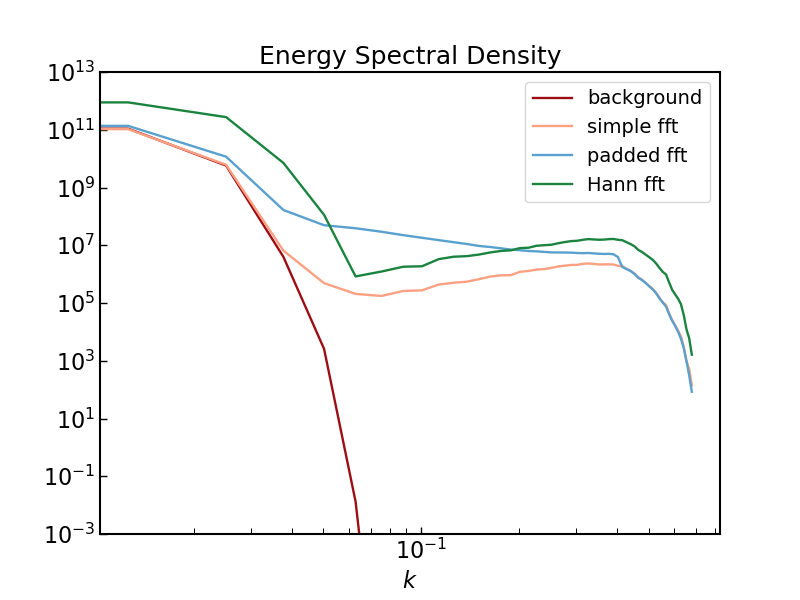

In [28]:
fig, ax = plt.subplots(figsize=(8,6))

tt = np.logspace(np.log10(2e-2), 0, 100)

ax.plot(k1d, powerspectrrho_backgr, ls='-', color=reds[1],
        markerfacecolor='none', label=r'background')

ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', color=reds[6],
        markerfacecolor='none', markersize=4, label=r'simple fft')

ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
        markerfacecolor='none', markersize=4, label=r'padded fft')

ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', color=greens[2],
        markerfacecolor='none', markersize=4, label=r'Hann fft ')

# ax.plot(k1d_mex.value, powerspectr_mex.value, ls='-', color=grays[5],
#         markerfacecolor='none', markersize=4, label=r'mex-hat')

# ax.plot(tt, 1e10*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')

ax.set_xlabel('$k$', fontsize=16)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='best',ncols=1,fontsize=14)

ax.set_title(r'Energy Spectral Density', fontsize=18)

# ax.set_xlim(xmin=1e-2)
ax.set_ylim(ymin=1e-3,ymax=1e13)
# ax.set_ylim(ymin=1e-20)
# ax[1].set_xlim(xmax=30)

# plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)
# plt.show()
